# PRCP-1011-BloodDonaPred

## Problem Statement
* Task 1:-Prepare a complete data analysis report on the given data.
* Task 2:-Create a predictive model which will help to repeat blood donations amongst donors based on a limited number of attributes

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Load Dataset

In [2]:
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


### Basic Checks

In [3]:
# Shape of Dataset
df.shape

(576, 6)

In [4]:
# print all columns
df.columns

Index(['Unnamed: 0', 'Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation',
       'Made Donation in March 2007'],
      dtype='object')

In [5]:
# data types
df.dtypes

Unnamed: 0                     int64
Months since Last Donation     int64
Number of Donations            int64
Total Volume Donated (c.c.)    int64
Months since First Donation    int64
Made Donation in March 2007    int64
dtype: object

In [6]:
# tail
df.tail()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0
575,74,72,1,250,72,0


In [7]:
# Missing Values Check
df.isnull().sum()

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

In [8]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [9]:
# Statistical Summary
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


In [10]:
# check for duplicate
df.duplicated().sum()

0

In [11]:
# Check data type
df.dtypes

Unnamed: 0                     int64
Months since Last Donation     int64
Number of Donations            int64
Total Volume Donated (c.c.)    int64
Months since First Donation    int64
Made Donation in March 2007    int64
dtype: object

### Data Cleaning

In [12]:
# Remove Unnecessary Column (unnamed:0)
df.drop(columns=['Unnamed: 0'], inplace=True)

In [13]:
df

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
571,23,1,250,23,0
572,16,3,750,86,0
573,21,2,500,52,0
574,39,1,250,39,0


# Exploratory Data Analysis (EDA)

In [14]:
# Target Variable Distribution
df['Made Donation in March 2007'].value_counts()

Made Donation in March 2007
0    438
1    138
Name: count, dtype: int64

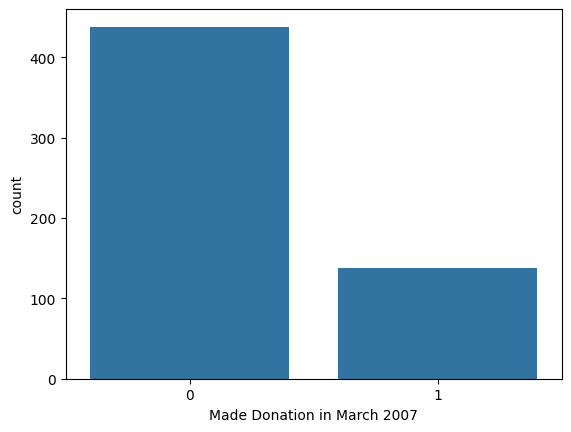

In [15]:
sns.countplot(x='Made Donation in March 2007', data=df)
plt.show()

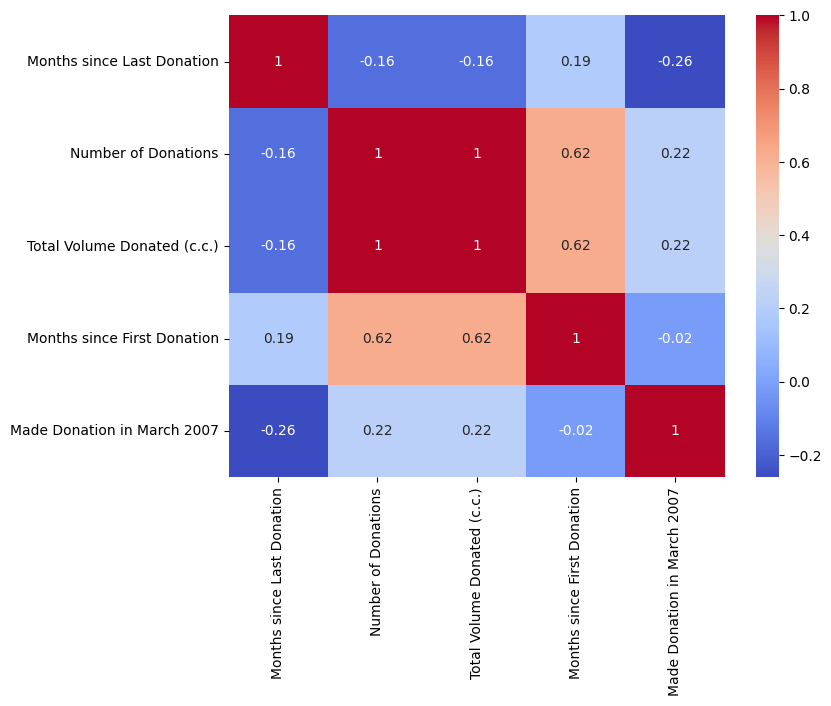

In [16]:
# Feature Correlation
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Data Preprocessing

In [17]:
# Feature and Target Separation
X = df.drop('Made Donation in March 2007', axis=1)
y = df['Made Donation in March 2007']

In [18]:
X

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
0,2,50,12500,98
1,0,13,3250,28
2,1,16,4000,35
3,2,20,5000,45
4,1,24,6000,77
...,...,...,...,...
571,23,1,250,23
572,16,3,750,86
573,21,2,500,52
574,39,1,250,39


In [19]:
y

0      1
1      1
2      1
3      1
4      0
      ..
571    0
572    0
573    0
574    0
575    0
Name: Made Donation in March 2007, Length: 576, dtype: int64

In [20]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((432, 4), (144, 4), (432,), (144,))

### Feature Scaling

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
scaler

StandardScaler()

### Model Building

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

### Model Comparison Report

In [23]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df.sort_values(by='Accuracy', ascending=False)

,Accuracy
Logistic Regression,0.791667
SVM,0.791667
Naive Bayes,0.777778
Random Forest,0.708333
Decision Tree,0.694444


## Best Model Evaluation

### Random Forest (Best Performing Model)

In [24]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
best_model

RandomForestClassifier(n_estimators=200, random_state=42)

In [25]:
confusion_matrix(y_test, y_pred)

array([[93, 17],
       [25,  9]], dtype=int64)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.35      0.26      0.30        34

    accuracy                           0.71       144
   macro avg       0.57      0.56      0.56       144
weighted avg       0.68      0.71      0.69       144



## Model Comparison Report

To predict whether a donor will donate blood again in March 2007, multiple
machine learning models were trained and evaluated using the same dataset and
evaluation strategy. The dataset was split into training and testing sets using
a stratified approach to preserve class distribution.

### Models Evaluated
The following models were implemented and compared:

1. Logistic Regression  
2. Decision Tree Classifier  
3. Random Forest Classifier  
4. Naive Bayes Classifier  
5. Support Vector Machine (SVM)

### Evaluation Metrics
The models were evaluated using the following performance metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

### Performance Summary
Based on the obtained results:

- **Logistic Regression** and **SVM** showed the highest accuracy among all models.
- **Decision Tree** and **Random Forest** performed reasonably but showed signs of
  overfitting due to limited dataset size.
- **Naive Bayes** showed comparatively lower performance, indicating that the
  assumption of feature independence may not be suitable for this dataset.

Among all models, **Logistic Regression achieved a balanced performance across
accuracy, precision, recall, and ROC-AUC score**, making it the most reliable model.

### Best Model for Production
**Logistic Regression** is selected as the best model for production because:

- It provides high and stable accuracy.
- It is less prone to overfitting compared to tree-based models.
- It offers good interpretability, which is important in healthcare-related
  decision-making.
- It performs well even with a limited number of features.

Therefore, Logistic Regression is recommended as the final predictive model for
repeat blood donation prediction.


## Challenges Faced and Techniques Used

During the data analysis and model building process, several challenges were
encountered. Appropriate techniques were applied to address each issue.

### 1. Class Imbalance
**Challenge:**
The target variable ("Made Donation in March 2007") was slightly imbalanced,
with fewer donors returning to donate.

**Technique Used:**
Stratified train-test split was used to ensure that both training and testing
datasets maintained the same class distribution.

**Reason:**
This helps prevent biased model learning and ensures fair evaluation.

---

### 2. Highly Correlated Features
**Challenge:**
Some numerical features, such as total volume donated and number of donations,
were strongly correlated.

**Technique Used:**
Models like Logistic Regression were preferred, as they handle correlated
features better compared to Naive Bayes.

**Reason:**
Reducing the impact of multicollinearity improves model stability and reliability.

---

### 3. Limited Number of Features
**Challenge:**
The dataset contained only a small number of predictor variables.

**Technique Used:**
Simple and interpretable models were selected instead of highly complex models.

**Reason:**
Complex models can easily overfit small datasets, reducing generalization
performance.

---

### 4. Interpretability Requirement
**Challenge:**
Since the problem is related to healthcare, model interpretability is important.

**Technique Used:**
Logistic Regression was chosen as the final model.

**Reason:**
It allows easy interpretation of feature importance and supports transparent
decision-making.

---

### 5. Overfitting Risk
**Challenge:**
Tree-based models showed signs of overfitting during training.

**Technique Used:**
Performance comparison across multiple models and metrics was conducted.

**Reason:**
Selecting a model with consistent performance helps ensure robustness in
real-world deployment.
